# Identification of factors

In this notebook, we use we use the already trained DRVI model on the immune dataset to identify biological processes captured by each latent factor. We combine multiple complementary annotation strategies:

1. **Cell type annotation** — match factors to known cell types using existing labels (SMI) and pre-trained classifiers (CellTypist)
2. **Annotation of Biological Processes** using
    * a. **Gene set enrichment analysis (GSEA)** — identify enriched pathways from ranked gene lists (BlitzGSEA)
    * b. **Over-representation analysis (ORA)** — test for enriched gene sets using ordered queries (g:Profiler)
    * c. **Regulator activity inference** — infer transcription factor or pathway activity using a statistical framework (decoupler) integrated with prior knowledge 

Each tool operates on the gene-level effect scores produced by DRVI's latent space traversal, which capture how gene expression changes when a latent factor is activated in either direction.

**We always advise examination by a biologist and validation against published literature for any identified processes.**

## Intro

This notebook assumes that you have already trained a DRVI model and run the interpretability pipeline (latent space traversal).

Please refer to the [General training and interpretability pipeline](./general_pipeline.html) tutorial.

While we use the immune dataset as a running example, all code is dataset-agnostic. Configuration variables at the top of each section indicate what to change for your own data.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, the next cell will install dependencies.

Please remove this part if your environment is already set up.

In [1]:
import sys
import subprocess

branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "drvi[tutorials]"])
elif IN_COLAB and branch != "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]"])

if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "celltypist", "blitzgsea", "gprofiler-official", "decoupler"])

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI

In [4]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.1
Last run with DRVI version: 0.2.2


In [5]:
# Making plots prettier
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (3, 3)

## Config

In [6]:
# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("/home/icb/clara.sanchez/data/drvi_immune_128")

# Set this to false if you already trained your model and do not like to retrain.
overwrite = False

# Significance threshold used across all tools
fdr_threshold = 0.05

## Load Data

In [7]:
# We already saved pre-processed data in previous notebook
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
adata

AnnData object with n_obs × n_vars = 32484 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    uns: 'batch_colors', 'final_annotation_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Load DRVI outputs

In [8]:
model_path = io_dir / "drvi_model"
embed_path = io_dir / "embed.h5ad"
traverse_adata_path = io_dir / "traverse_adata.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)
traverse_adata = sc.read_h5ad(traverse_adata_path)

INFO     File /home/icb/clara.sanchez/data/drvi_immune_128/drvi_model/model.pt already downloaded                  
INFO     DRVI: The model is trained with DRVI version 0.2.1.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.2.                                  
INFO     DRVI: Loading model from DRVI version 0.2.1.                                                              
INFO     DRVI: Modifying model args from 0.2.1 to 0.2.2 (no user action required)                                  
INFO     DRVI: Removing prior_init_obs from model args.                                                            
INFO     DRVI: Done updating model args. Loading in 0.2.2.                                                         
INFO     DRVI: The model has been initialized                           

## 0. Prepare shared inputs

All annotation tools operate on the gene-level effect scores from DRVI's latent space traversal. For each latent factor, traversing in the positive (+) or negative (−) direction produces a vector of per-gene scores that quantify how much each gene's predicted expression changes. These scores serve as:

- **Ranked gene lists** for GSEA-style tools (BlitzGSEA)
- **Ordered gene queries** for ORA-style tools (g:Profiler)
- **Gene × factor score matrices** for decoupler which uses statistical models (like ULM or MLR) to infer regulator activity by integrating these scores with a prior knowledge network

We prepare these shared inputs once and reuse them across all tools.

In [9]:
# Remove vanished dimensions
embed_nv = embed[:, ~embed.var["vanished"].astype(bool)].copy()
factor_ids = embed_nv.var["title"].astype(str).tolist()
print(f"Active (non-vanished) factors: {embed_nv.n_vars}")

# Extract per-gene traverse effect scores (genes x factors)
# These capture how gene expression changes when each latent factor is traversed
pos_df = traverse_adata.varm["combined_score_traverse_effect_pos"].copy()
neg_df = traverse_adata.varm["combined_score_traverse_effect_neg"].copy()

# Filter to non-vanished dimensions
vanished_mask = ~embed.var["vanished"].astype(bool).values
if pos_df.shape[1] == len(vanished_mask):
    pos_df = pos_df.iloc[:, vanished_mask].copy()
    neg_df = neg_df.iloc[:, vanished_mask].copy()

pos_df.columns = factor_ids
neg_df.columns = factor_ids

# Background gene universe: all genes measured in the experiment (before HVG filtering).
raw_data_path = io_dir / "immune_all.h5ad"  
adata_full = sc.read_h5ad(raw_data_path, backed="r")

all_genes = adata_full.var_names.astype(str).str.strip().str.upper()
adata_full.file.close()
all_genes = pd.Index(all_genes).drop_duplicates().tolist()
print(f"Background genes: {len(all_genes)}")

Active (non-vanished) factors: 61
Background genes: 12303


In [12]:
# Build enrichment inputs from a genes x factors score matrix

# Returns
# std : DataFrame: Standardized genes x factors scores (uppercased, duplicates merged by max).
# ranked : dict {factor: Series sorted by descending score} for GSEA tools.

def build_inputs(df, all_genes=all_genes):
    std = df.copy()
    std.index = std.index.astype(str).str.strip().str.upper()
    std = std.groupby(std.index).max()

    if all_genes is not None:
        idx = pd.Index(pd.Series(all_genes).astype(str)).drop_duplicates()
        std = std.reindex(idx)

    ranked = {c: std[c].dropna().sort_values(ascending=False) for c in std.columns}
    return std, ranked


pos_std, pos_ranked = build_inputs(pos_df)
neg_std, neg_ranked = build_inputs(neg_df)

# Factor-direction labels used throughout (e.g., "DR 36+")
factor_dir_labels = [f"{f}+" for f in factor_ids] + [f"{f}-" for f in factor_ids]

print(f"Factors: {len(factor_ids)}")
print(f"Factor-directions: {len(factor_dir_labels)}")
print(f"Genes per ranked list: {len(next(iter(pos_ranked.values())))}")

Factors: 61
Factor-directions: 122
Genes per ranked list: 2000


## 1. Cell type annotation

Some latent factors capture cell-type identity. We can identify these using:
- **Known annotations** (if available): measure alignment between factors and annotated cell types via Scaled Mutual Information (SMI)
- **CellTypist**: classify cells using pre-trained models and correlate class probabilities with factor activities

#### Cell Type Annotation Config

In [13]:
# Column in adata.obs containing cell type labels. Set to None if not available.
annot_col = "final_annotation" 

smi_threshold = 0.5 # Minimum SMI score between factor and cell-type probability
spec_threshold = 0.1 # Minimum specificity (gap between best and second-best correlation)

### 1.1 Known annotations (SMI)

If your dataset has existing cell type annotations, Scaled Mutual Information (SMI) measures how well each latent factor aligns with each annotated category. SMI is normalized to [0, 1], where 1 indicates perfect correspondence between a factor and a cell type.

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.

We first measure Scaled Mutual Information (SMI) between each latent dimension and each category using DRVI built-in functions.

**Skip this section if your dataset does not have cell type annotations.**

#### Specific Imports

In [14]:
import math
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

#### Scaled Mutual Information

In [15]:
benchmark = DiscreteDisentanglementBenchmark(
    embed_nv.X,
    dim_titles=embed_nv.var["title"],
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc"],
    aggregation_methods=["LMS"],
)
benchmark.evaluate()

# You can optionally save benchmark object if you want.
# benchmark.save(filename)

In [16]:
smi_similarity = benchmark.get_results_details()["SMI-disc"]
print(f"SMI matrix shape: {smi_similarity.shape} (factors x cell types)")
display(smi_similarity.head())

SMI matrix shape: (61, 16) (factors x cell types)


,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 36,0.021124,0.007055,0.013579,0.005682,0.003340,0.006009,0.012808,0.025647,0.141675,0.147504,0.652945,0.023091,0.009346,0.006856,0.019912,0.010587
DR 49,0.058937,0.010312,0.003151,0.115108,0.019689,0.012800,0.006262,0.002189,0.002379,0.001219,0.001292,0.004543,0.008689,0.017035,0.859131,0.003900
DR 33,0.030350,0.011059,0.030578,0.021986,0.009531,0.011717,0.048552,0.468666,0.061815,0.370950,0.022623,0.007081,0.010243,0.011877,0.009066,0.005726
DR 38,0.017637,0.007678,0.008826,0.008149,0.012777,0.123699,0.004518,0.050416,0.004173,0.049967,0.008930,0.026165,0.005970,0.006707,0.018673,0.009291
DR 2,0.140299,0.080318,0.033397,0.761070,0.048512,0.084590,0.070976,0.036295,0.033788,0.033796,0.033385,0.107270,0.063494,0.064894,0.035367,0.038994


In [17]:
smi_top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars="title", value_vars=smi_similarity.columns)
    .query("value >= @smi_threshold")
    .reset_index(drop=True)
)
print(f"Factor–cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
display(smi_top_matches.sort_values("value", ascending=False))

Factor–cell type pairs with SMI >= 0.5: 24


,title,variable,value
23,DR 17,Plasmacytoid dendritic cells,0.929396
22,DR 28,Plasma cells,0.914106
7,DR 9,CD16+ Monocytes,0.910748
5,DR 3,CD14+ Monocytes,0.878655
21,DR 49,Plasma cells,0.859131
19,DR 18,Monocyte-derived dendritic cells,0.791458
2,DR 53,CD10+ B cells,0.773828
4,DR 2,CD14+ Monocytes,0.761070
8,DR 5,CD20+ B cells,0.758002
15,DR 21,HSPCs,0.736581


#### Visualize with a Heatmap

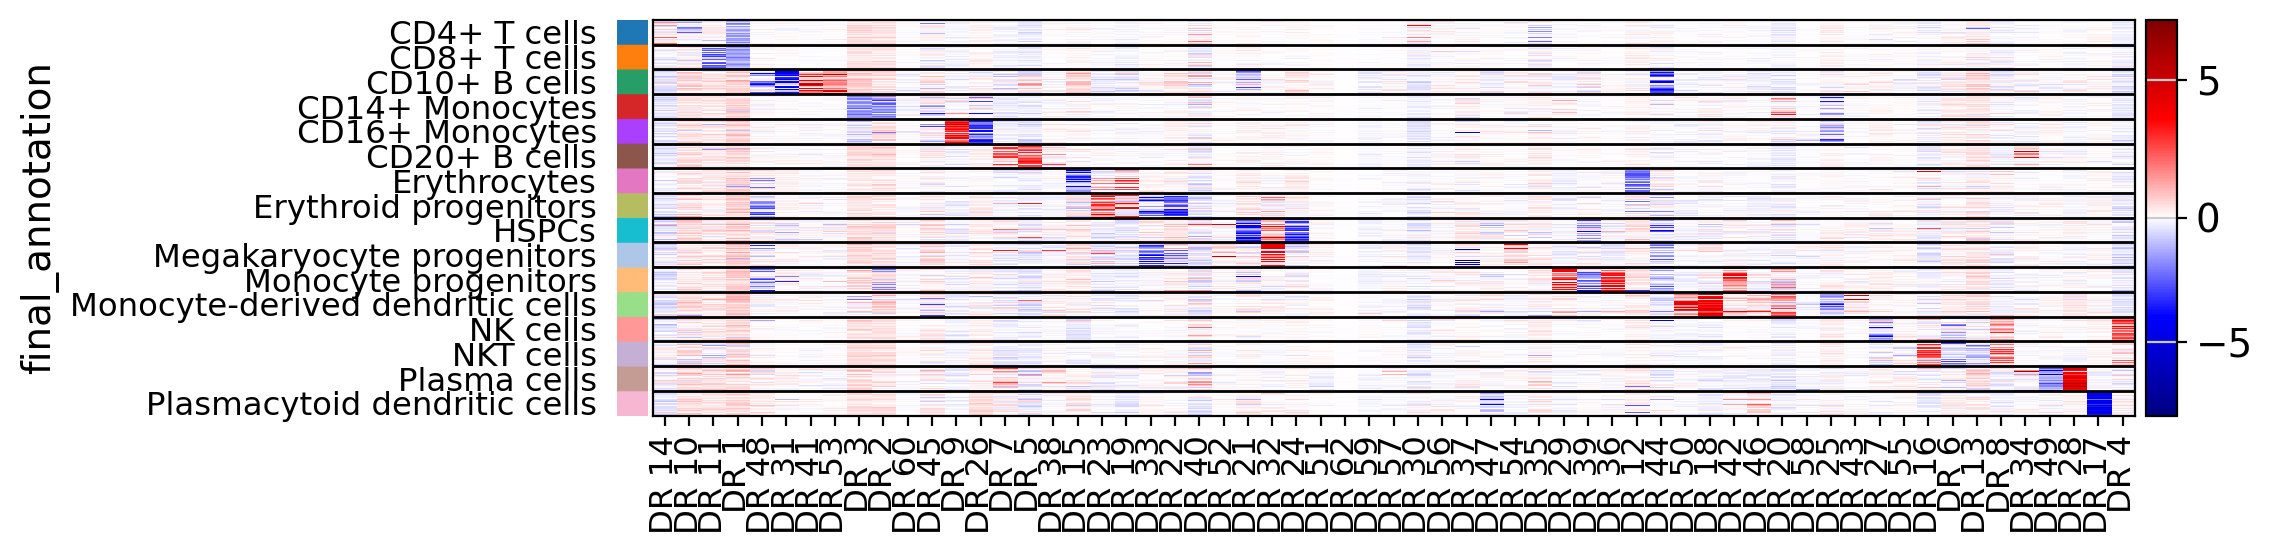

In [18]:
drvi.utils.pl.plot_latent_dims_in_heatmap(
    embed, annot_col, title_col="title", sort_by_categorical=True
)

#### Helper function for Plot Packed Network Visualization

In [19]:
def plot_packed_network(df, title_col="title", var_col="variable", val_col="value"):
    """Visualizes factor–cell type associations as a network with edge weights."""
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)

    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = math.ceil(len(components) ** 0.5)
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=(14, 10))
    titles = set(df[title_col])
    nx.draw(
        G, pos,
        with_labels=True, font_size=8, font_weight="bold", node_size=600,
        node_color=["#A0CBE2" if n in titles else "#FF9E9E" for n in G.nodes()],
        width=[d[val_col] * 4 for u, v, d in G.edges(data=True)],
        edge_color="grey", alpha=0.6,
    )
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.axis("off")
    plt.show()

#### Plot Packed Visualization

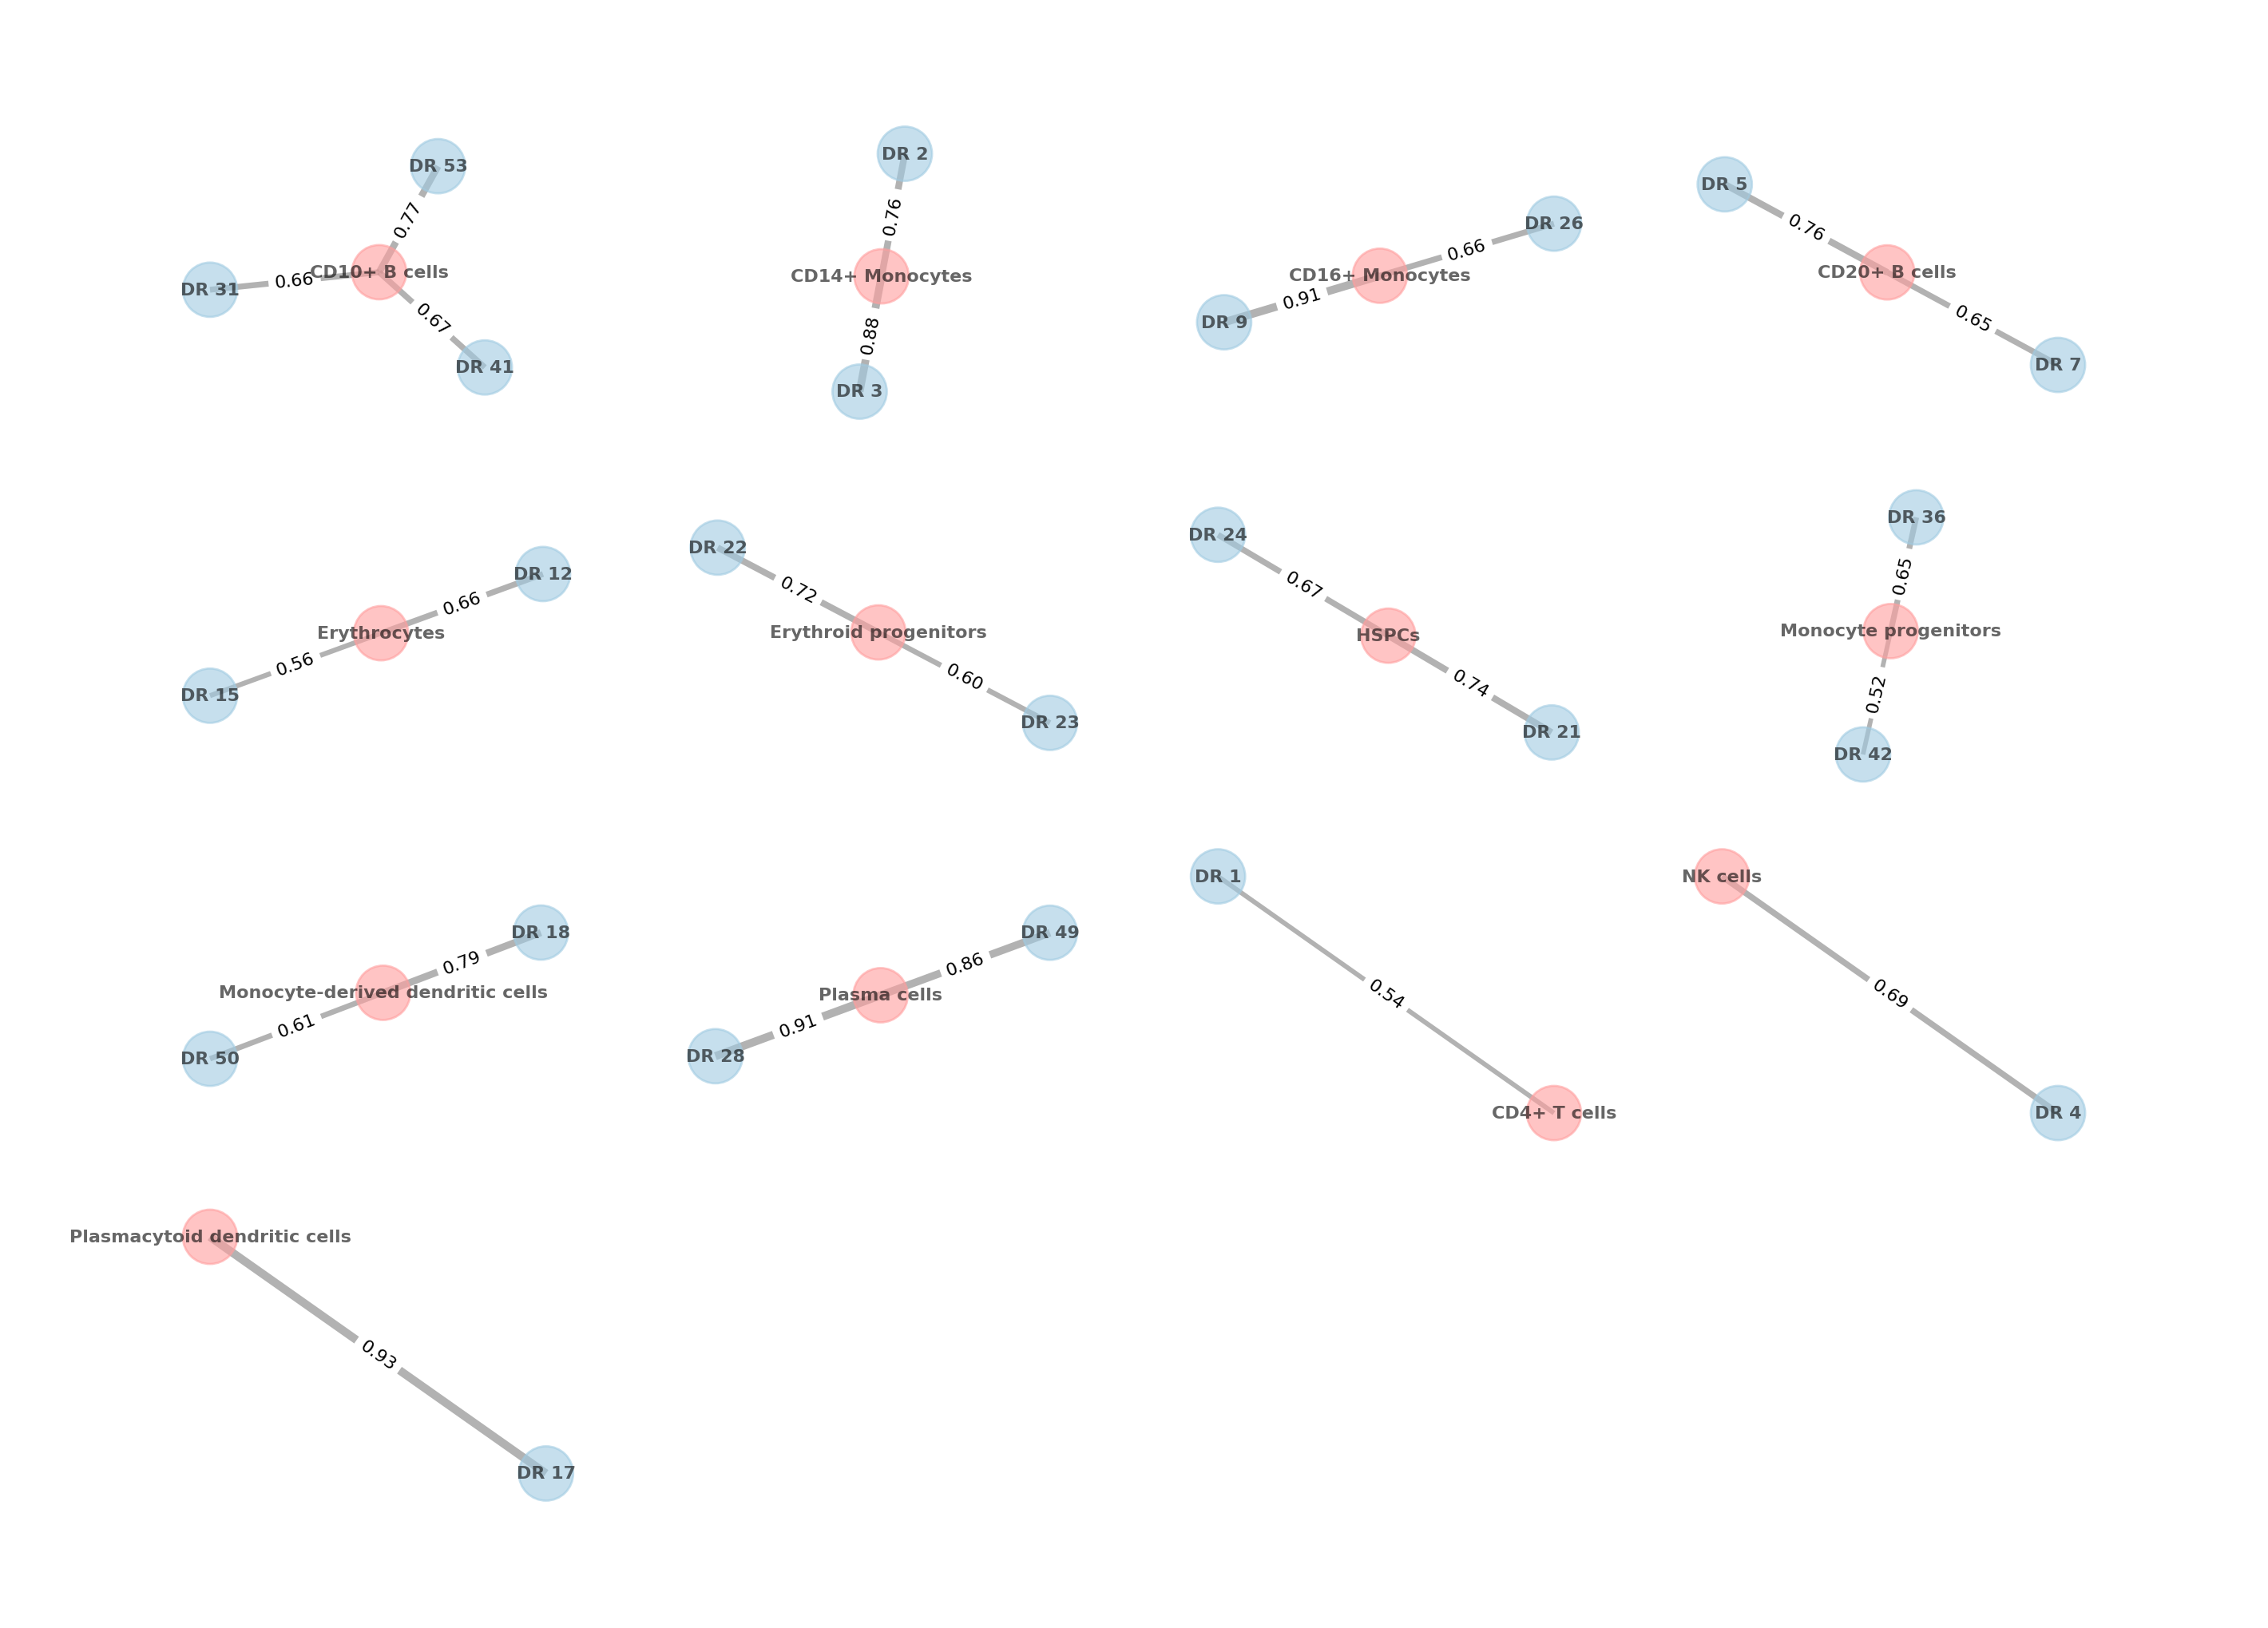

In [20]:
plot_packed_network(smi_top_matches)

### 1.2 CellTypist

[CellTypist](https://www.celltypist.org/) uses pre-trained logistic regression models trained on large-scale annotated atlases to classify individual cells. We calculate the Similarity Mutual Information (SMI) between the CellTypist probability matrix (cells × cell types) and the DRVI factor activity matrix (cells × factors) to identify which factors correspond to which cell types.

**Skip this section if no CellTypist model matches your tissue.**


#### Imports

In [21]:
import celltypist
from celltypist import models

#### CellTypist Model

In [22]:
# Run celltypist.models.models_description() to see all available models. Choose one matching your tissue. 
ct_model = "Immune_All_Low.pkl"  # e.g., "Developing_Mouse_Brain.pkl" for mouse brain
models.download_models(force_update=False, model=ct_model)

#load model
ct_model = models.Model.load(model=ct_model)

#  Run print(CT_MODEL.cell_types) to see cell types from the model

📂 Storing models in /home/icb/clara.sanchez/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


#### CellTypist Annotation

In [23]:
# 1. Each cell receives a predicted label via logistic regression based on its transcriptomic profile.
# 2. majority_voting=True refines these labels by assigning the most frequent label within a cell's local neighborhood (kNN), reducing technical noise.

# Output: per-cell labels are extracted from the predictions object and stored in adata.obs.
predictions = celltypist.annotate(adata, model=ct_model, majority_voting=True)
adata.obs["celltypist_labels"] = predictions.predicted_labels["predicted_labels"]
adata.obs["celltypist_majority"] = predictions.predicted_labels["majority_voting"]

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 32484 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1569 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


#### Extract Probability Matrix

In [24]:
# Probability matrix: sigmoid-transformed decision scores (cells x cell types)
prob_matrix = predictions.probability_matrix
prob_matrix.index = adata.obs_names
print(f"Probability matrix: {prob_matrix.shape[0]} cells x {prob_matrix.shape[1]} cell types")

Probability matrix: 32484 cells x 98 cell types


#### CellTyist Mutual Information

In [26]:
titles = embed_nv.var["title"].astype(str).tolist()
pos_embed = np.maximum(embed_nv.X, 0)
neg_embed = np.maximum(-embed_nv.X, 0)

split_embed = np.column_stack([
    arr for i in range(embed_nv.X.shape[1])
    for arr in (pos_embed[:, i:i+1], neg_embed[:, i:i+1])
])
split_titles = [f"{t}{s}" for t in titles for s in ["+", "-"]]

ct_benchmark = DiscreteDisentanglementBenchmark(
    split_embed,
    dim_titles=split_titles,
    discrete_target=adata.obs.loc[embed_nv.obs_names, "celltypist_majority"],
    metrics=["SMI-disc"],
    aggregation_methods=["LMS"],
)
ct_benchmark.evaluate()

# smi: factors x CellTypist-predicted cell-types matrix
ct_smi_matrix = ct_benchmark.get_results_details()["SMI-disc"]
print(f"CellTypist SMI matrix: {ct_smi_matrix.shape} (factor-directions x CellTypist labels)")

CellTypist SMI matrix: (122, 24) (factor-directions x CellTypist labels)


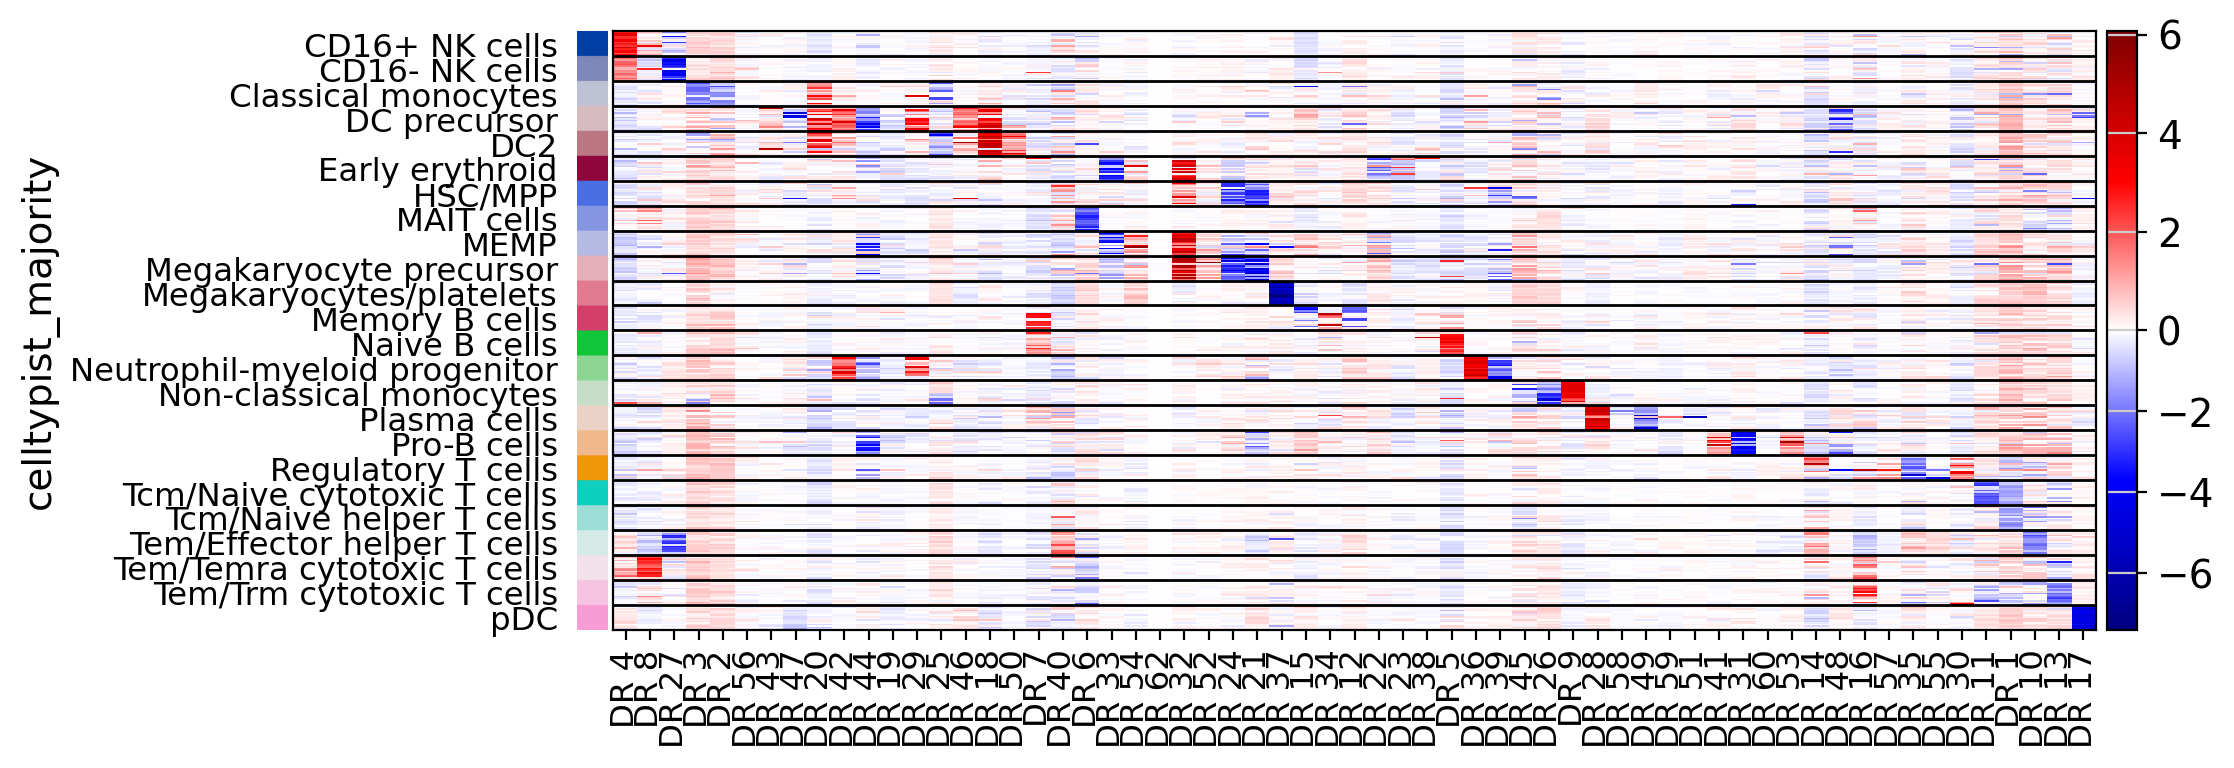

In [27]:
embed.obs["celltypist_majority"] = adata.obs.loc[embed.obs_names, "celltypist_majority"].values

drvi.utils.pl.plot_latent_dims_in_heatmap(
    embed, "celltypist_majority", title_col="title", sort_by_categorical=True
)

#### Summary Table

In [30]:
# Top CellTypist match per factor-direction
idx_name = ct_smi_matrix.index.name or "index"
ct_long = (
    ct_smi_matrix.reset_index()
    .melt(id_vars=idx_name, var_name="cell_type", value_name="smi")
    .rename(columns={idx_name: "factor"})
    .sort_values("smi", ascending=False)
    .drop_duplicates(subset="factor", keep="first")
)

ct_significant = ct_long.query("smi >= @smi_threshold").copy()

print(f"CellTypist matches with SMI >= {smi_threshold}: {len(ct_significant)} / {len(ct_long)} factor-directions")
display(ct_significant.sort_values("smi", ascending=False))

CellTypist matches with SMI >= 0.5: 29 / 122 factor-directions


,factor,cell_type,smi
2915,DR 17-,pDC,0.957552
1283,DR 37-,Megakaryocytes/platelets,0.914588
1932,DR 28+,Plasma cells,0.913778
78,DR 4+,CD16+ NK cells,0.881255
1828,DR 9+,Non-classical monocytes,0.872452
1586,DR 36+,Neutrophil-myeloid progenitor,0.823990
291,DR 3-,Classical monocytes,0.821163
1498,DR 5+,Naive B cells,0.811494
829,DR 21-,HSC/MPP,0.804409
1833,DR 49-,Plasma cells,0.794328


## 2. Biological process identification

Factors that do not map to a single cell type often capture biological processes (e.g., interferon response, cell cycle, stress). We use three complementary enrichment approaches, each with different strengths:

| Tool | Method | Input | Strengths |
|------|--------|-------|-----------|
| **BlitzGSEA** | Pre-ranked GSEA | Full ranked gene list | Fast; uses entire ranking; uses an analytical null distribution |
| **g:Profiler** | Over-representation (ORA) | Ordered gene query | Robust multiple-testing (g:SCS); well-suited for biological pathways and GO terms |
| **decoupler** | Activity Inference (ULM/MLM) | Gene score matrix + Prior Knowledge | Regression-based; identifies specific regulatory drivers (e.g., TFs) using curated networks |

### 2.1 BlitzGSEA

[BlitzGSEA](https://github.com/MaayanLab/blitzgsea) performs pre-ranked Gene Set Enrichment Analysis using an analytical approximation of the null distribution rather than permutations, enabling high-performance enrichment testing across many factors.

- **Input**: Full ranked gene list (genes sorted by their DRVI effect scores, capturing the magnitude and direction of expression change)
- **Output**: Normalized Enrichment Score (NES) and FDR-adjusted p-values per gene set
- **Database**: Compatible with any standard .gmt file or Enrichr library (e.g., MSigDB, Reactome)

In [31]:
# Enrichr library to use. See Appendix for available databases.
# Common choices: "MSigDB_Hallmark_2020", "GO_Biological_Process_2023",
#                 "Reactome_2022", "KEGG_2021_Human"

gsea_db = "MSigDB_Hallmark_2020"

In [32]:
import blitzgsea as blitz

signature_lib = blitz.enrichr.get_library(gsea_db)
print(f"Loaded {gsea_db}: {len(signature_lib)} gene sets")

Loaded MSigDB_Hallmark_2020: 50 gene sets


In [33]:
blitzgsea_rows = []

for fac in factor_ids:
    for direction, ranked_dict in [("pos", pos_ranked), ("neg", neg_ranked)]:
        factor_label = f"{fac}+" if direction == "pos" else f"{fac}-"
        series = ranked_dict[fac]

        # BlitzGSEA expects a DataFrame with columns "i" (gene) and "v" (score)
        signature = series.rename("v").reset_index().rename(columns={"index": "i"})
        signature["v"] = pd.to_numeric(signature["v"], errors="coerce")
        signature = signature.replace([np.inf, -np.inf], np.nan).dropna(subset=["v"])

        try:
            res = blitz.gsea(signature, signature_lib, processes=4)
            sig = res[res["fdr"] < fdr_threshold].sort_values("fdr")
            if len(sig):
                blitzgsea_rows.append({
                    "factor": factor_label,
                    "term": sig.index[0],
                    "NES": round(float(sig.iloc[0]["nes"]), 3),
                    "FDR": float(sig.iloc[0]["fdr"]),
                })
        except Exception:
            pass

blitzgsea_results = pd.DataFrame(blitzgsea_rows)
print(f"BlitzGSEA significant hits: {len(blitzgsea_results)} / {len(factor_dir_labels)} factor-directions")
display(blitzgsea_results.sort_values("FDR"))

BlitzGSEA significant hits: 11 / 122 factor-directions


,factor,term,NES,FDR
1,DR 29+,Pperoxisome,-5.526,0.000002
3,DR 39-,Pperoxisome,-4.646,0.000162
6,DR 54-,IL-6/JAK/STAT3 Signaling,4.341,0.000680
7,DR 48-,KRAS Signaling Up,-4.117,0.001839
10,DR 4-,Epithelial Mesenchymal Transition,3.974,0.003399
5,DR 3+,KRAS Signaling Up,-3.600,0.008611
8,DR 56+,Epithelial Mesenchymal Transition,-3.706,0.010097
2,DR 5-,Epithelial Mesenchymal Transition,-3.569,0.017222
0,DR 55-,Fatty Acid Metabolism,-3.525,0.020310
4,DR 40-,Glycolysis,-3.243,0.035036


### 3.2 g:Profiler

[g:Profiler](https://biit.cs.ut.ee/gprofiler/) performs Over-Representation Analysis (ORA) using a hypergeometric test. It employs a custom multiple-testing correction (g:SCS), which is specifically optimized to handle the hierarchical and overlapping structure of Gene Ontology terms.

In **ordered query** mode, g:Profiler processes genes sorted by their DRVI effect scores and iteratively tests enrichment at increasing increments. This approach automatically identifies the optimal gene set size for enrichment, making it more sensitive than using a fixed "top-N" cutoff for continuous latent factor scores.

- **Input**: Ordered gene list (genes sorted by absolute or directional traverse effect scores)
- **Output**: Enriched terms with p-values corrected via g:SCS
- **Database**: Comprehensive support for GO (BP, MF, CC), Reactome, KEGG, WikiPathways, and regulatory motifs

In [34]:
# Organism string. Common values: "hsapiens", "mmusculus", "drerio"
organism = "hsapiens"

# Source database(s). Query one at a time for best results.
# Common choices: ["GO:BP"], ["GO:MF"], ["GO:CC"], ["REAC"], ["KEGG"], ["HP"]
gp_source = ["GO:BP"]

In [35]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)


def run_gprofiler_for_factor(genes, factor_label):
    """Run g:Profiler ordered-query ORA for a single factor-direction."""
    genes = pd.Series(genes).dropna().astype(str).drop_duplicates().tolist()
    if not genes:
        return pd.DataFrame()

    res = gp.profile(
        organism=organism,
        query=genes,
        sources=gp_source,
        ordered=True,
        user_threshold=fdr_threshold,
        background=all_genes,
    )
    if res is None or res.empty:
        return pd.DataFrame()

    res = res.copy()
    res["factor"] = factor_label
    return res

In [ ]:
gprofiler_parts = []

for fac in factor_ids:
    for direction, ranked_dict in [("pos", pos_ranked), ("neg", neg_ranked)]:
        factor_label = f"{fac}+" if direction == "pos" else f"{fac}-"
        genes = ranked_dict[fac].index.tolist()
        gprofiler_parts.append(run_gprofiler_for_factor(genes, factor_label))

gprofiler_all = pd.concat(
    [x for x in gprofiler_parts if not x.empty], ignore_index=True
) if any(not x.empty for x in gprofiler_parts) else pd.DataFrame()

# Keep top-1 per factor-direction (lowest p-value)
if not gprofiler_all.empty:
    gprofiler_results = (
        gprofiler_all.sort_values("p_value")
        .groupby("factor", as_index=False)
        .first()
        [["factor", "name", "p_value", "intersection_size"]]
        .rename(columns={"name": "term"})
    )
    gprofiler_results["p_value"] = gprofiler_results["p_value"].astype(float)
    gprofiler_results = gprofiler_results[gprofiler_results["p_value"] < fdr_threshold]
else:
    gprofiler_results = pd.DataFrame(columns=["factor", "term", "p_value", "intersection_size"])

print(f"g:Profiler significant hits: {len(gprofiler_results)} / {len(factor_dir_labels)} factor-directions")
display(gprofiler_results.sort_values("p_value"))

### 3.3 decoupler

[decoupler](https://decoupler-py.readthedocs.io/) uses regression-based methods (Univariate/Multivariate Linear Models, z-score) and weighted sums to infer the activity of regulators from gene-level scores. Unlike enrichment-based methods, it models the relationship between observed gene scores and a Prior Knowledge Network (PKN), quantifying the specific influence of a regulator

decoupler provides access to curated regulatory networks from [OmniPath](https://omnipathdb.org/) that are not available through Enrichr:
- **CollecTRI**: A comprehensive, curated network of transcription factor (TF) → target gene interaction
- **DoRothEA**: TF regulons categorized by confidence levels (A–D) based on supporting evidence
- **PROGENy**:A resource that infers pathway activity (e.g., Hypoxia, EGFR, TGFb) based on the expression of downstream responsive genes

Multiple methods are run in parallel and combined via Stouffer's consensus to produce robust p-values.

In [ ]:
# Gene set / network to use.
# Options: "collectri", "dorothea", "progeny"
dc_geneset = "progeny"

# Organism. Must match ORGANISM above: "human" for hsapiens, "mouse" for mmusculus
dc_organism = "human"

dc_methods = ["ulm", "mlm", "zscore"] 
dc_min = 5

In [ ]:
import decoupler as dc
from statsmodels.stats.multitest import multipletests

In [ ]:
net_dispatch = {
    "collectri": lambda: dc.op.collectri(organism=dc_organism),
    "dorothea": lambda: dc.op.dorothea(organism=dc_organism, levels=["A", "B", "C"]),
    "progeny": lambda: dc.op.progeny(organism=dc_organism),
}
net = net_dispatch.get(
    dc_geneset.strip().lower(),
    lambda: dc.op.resource(name=dc_geneset, organism=dc_organism),
)()

cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)
print(f"Network: {len(net)} interactions, {net['source'].nunique()} regulators")

In [ ]:
def run_decouple(df_factors_by_genes, direction_label):
    """Run decoupler consensus on a factors x genes score matrix."""
    mat = df_factors_by_genes.copy()
    mat.columns = mat.columns.astype(str).str.strip().str.upper()
    mat = mat.reindex(columns=all_genes, fill_value=0.0)
    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    net_use = net.copy()
    net_use["target"] = net_use["target"].astype(str).str.strip().str.upper()

    res = dc.mt.decouple(
        data=mat,
        net=net_use,
        methods=dc_methods,
        cons=False,
        tmin=dc_min,
        verbose=False,
    )
    _, pvals = dc.mt.consensus(res)

    out = pvals.stack().rename("p_value").reset_index()
    out.columns = ["factor_raw", "term", "p_value"]

    # BH correction for FDR comparability with other tools
    _, p_adj, _, _ = multipletests(out["p_value"].values, method="fdr_bh")
    out["p_adj"] = p_adj

    suffix = "+" if direction_label == "pos" else "-"
    out["factor"] = out["factor_raw"].astype(str) + suffix
    return out[["factor", "term", "p_value", "p_adj"]]


dec_pos = run_decouple(pos_std.T, "pos")
dec_neg = run_decouple(neg_std.T, "neg")
decoupler_all = pd.concat([dec_pos, dec_neg], ignore_index=True)

# Keep significant top-1 per factor-direction
decoupler_results = (
    decoupler_all[decoupler_all["p_adj"] < fdr_threshold]
    .sort_values("p_adj")
    .groupby("factor", as_index=False)
    .first()
    [["factor", "term", "p_adj"]]
)

print(f"decoupler significant hits: {len(decoupler_results)} / {len(factor_dir_labels)} factor-directions")
display(decoupler_results.sort_values("p_adj"))

## 4. Curation table and export

We now merge evidence from all tools into a single curation table. Each row represents one factor-direction, with the top hit from each tool (if significant) shown in a compact format. The table also includes the top 10 genes driving each factor-direction to facilitate manual validation via literature or LLMs.

The workflow is:
1. Build and export the curation table as CSV
2. Review and fill in `manual_label` / `manual_notes`
3. Re-import and store final annotations in the embedding object

In [ ]:
# Build the base table: all factor-directions with top 10 genes
curation_rows = []
for fac in factor_ids:
    for direction, ranked_dict in [("pos", pos_ranked), ("neg", neg_ranked)]:
        factor_label = f"{fac}+" if direction == "pos" else f"{fac}-"
        top_genes = ", ".join(ranked_dict[fac].head(10).index.tolist())
        curation_rows.append({"factor": factor_label, "top_genes": top_genes})

curation = pd.DataFrame(curation_rows)

# CellTypist column (factor-level, applies to both directions)
ct_map = {}
if len(ct_significant):
    for _, row in ct_significant.iterrows():
        summary = f"{row['top_cell_type']} || corr={row['correlation']} || spec={row['specificity']}"
        ct_map[f"{row['factor']}+"] = summary
        ct_map[f"{row['factor']}-"] = summary
curation["celltypist"] = curation["factor"].map(ct_map).fillna("")

# BlitzGSEA column
bg_map = {}
if len(blitzgsea_results):
    for _, row in blitzgsea_results.iterrows():
        bg_map[row["factor"]] = f"{row['term']} || NES={row['NES']} || FDR={row['FDR']:.2e}"
curation["blitzgsea"] = curation["factor"].map(bg_map).fillna("")

# g:Profiler column
gp_map = {}
if len(gprofiler_results):
    for _, row in gprofiler_results.iterrows():
        gp_map[row["factor"]] = f"{row['term']} || p={row['p_value']:.2e}"
curation["gprofiler"] = curation["factor"].map(gp_map).fillna("")

# decoupler column
dc_map = {}
if len(decoupler_results):
    for _, row in decoupler_results.iterrows():
        dc_map[row["factor"]] = f"{row['term']} || p_adj={row['p_adj']:.2e}"
curation["decoupler"] = curation["factor"].map(dc_map).fillna("")

# Empty columns for manual curation
curation["manual_label"] = ""
curation["manual_notes"] = ""

display(curation)

In [ ]:
curation_path = io_dir / "factor_annotation_curation.csv"
curation.to_csv(curation_path, index=False)
print(f"Curation table exported to: {curation_path}")
print("\nReview this CSV, fill in 'manual_label' and 'manual_notes' for factors")
print("that need manual curation, then re-run the cells below to finalize.")

### 4.1 Re-import and finalize

After reviewing and editing the CSV, re-import it to store final annotations in the embedding object. The `final_label` is taken from `manual_label` if provided; otherwise it falls back to the best available tool hit.

In [ ]:
curation_edited = pd.read_csv(curation_path)

def pick_final_label(row):
    """Pick final annotation: manual > celltypist > blitzgsea > gprofiler > decoupler."""
    if pd.notna(row.get("manual_label")) and str(row["manual_label"]).strip():
        return str(row["manual_label"]).strip(), "manual"
    for tool_col in ["celltypist", "blitzgsea", "gprofiler", "decoupler"]:
        val = row.get(tool_col, "")
        if pd.notna(val) and str(val).strip():
            term = str(val).split(" || ")[0].strip()
            return term, tool_col
    return "", "none"

labels_and_sources = curation_edited.apply(pick_final_label, axis=1, result_type="expand")
curation_edited["final_label"] = labels_and_sources[0]
curation_edited["label_source"] = labels_and_sources[1]

display(curation_edited[["factor", "final_label", "label_source"]].head(20))

In [ ]:
# Store annotations in embed.var for persistence
# Map factor-direction labels back to factor base names for embed.var
# We take the "+" direction label as the primary annotation per factor
annot_by_factor = {}
for _, row in curation_edited.iterrows():
    fac_base = row["factor"][:-1]  # strip +/- suffix
    direction = row["factor"][-1]
    if direction == "+" and row["final_label"]:
        annot_by_factor[fac_base] = (row["final_label"], row["label_source"])
    elif fac_base not in annot_by_factor and row["final_label"]:
        annot_by_factor[fac_base] = (row["final_label"], row["label_source"])

embed.var["annotation_final"] = embed.var["title"].map(
    lambda t: annot_by_factor.get(t, ("", ""))[0]
)
embed.var["annotation_source"] = embed.var["title"].map(
    lambda t: annot_by_factor.get(t, ("", ""))[1]
)

print("Annotations stored in embed.var:")
display(embed.var[["title", "vanished", "annotation_final", "annotation_source"]].head(20))

In [ ]:
embed.write_h5ad(embed_path)
print(f"Updated embedding saved to: {embed_path}")

## 5. Visual validation

Sanity-check a few annotated factors by visualizing their activity on the UMAP alongside the assigned cell type or biological process.

In [ ]:
# Pick example factors to validate (adjust for your dataset)
# Select factors that received annotations
annotated_factors = embed.var[
    (~embed.var["vanished"].astype(bool)) & (embed.var["annotation_final"] != "")
][["title", "annotation_final", "annotation_source"]]

print(f"Annotated factors: {len(annotated_factors)}")
display(annotated_factors.head(10))

In [ ]:
# Visualize 2-3 example factors (update dim_subset for your dataset)
example_dims = annotated_factors["title"].head(3).tolist()

if example_dims:
    drvi.utils.pl.show_differential_vars_scatter_plot(
        traverse_adata,
        key_x="max_possible",
        key_y="min_possible",
        key_combined="combined_score",
        dim_subset=[d + "-" for d in example_dims] + [d + "+" for d in example_dims],
        score_threshold=0.0,
    )

In [ ]:
if example_dims:
    for fig in drvi.utils.pl.plot_relevant_genes_on_umap(
        adata,
        embed,
        traverse_adata,
        traverse_adata_key="combined_score",
        dim_subset=[d + "-" for d in example_dims] + [d + "+" for d in example_dims],
        score_threshold=0.0,
    ):
        plt.show()

In [ ]:
if annot_col is not None and example_dims:
    drvi_factors_df = pd.DataFrame(embed_nv.X, index=embed_nv.obs_names, columns=factor_ids)
    for dim in example_dims:
        if dim in drvi_factors_df.columns:
            adata.obs["_factor_check"] = drvi_factors_df[dim].reindex(adata.obs_names).values
            annot = embed.var.set_index("title").loc[dim, "annotation_final"]
            print(f"\n{dim} — annotated as: {annot}")

            sc.pl.umap(
                adata,
                color=["_factor_check", annot_col],
                ncols=2,
                frameon=False,
                title=[f"Factor: {dim}", annot_col],
            )

            sc.pl.violin(
                adata,
                keys="_factor_check",
                groupby=annot_col,
                rotation=90,
            )

## Appendix: Database reference

The table below lists curated databases available for factor annotation, organized by domain. You can swap any of the tool-specific config variables above (e.g., `GSEA_DB`, `GP_SOURCE`, `DC_GENESET`) to use different databases.


### Biological process databases

| Database | Description | BlitzGSEA / GSEApy | g:Profiler | decoupler |
|----------|-------------|-------------------|------------|----------|
| MSigDB Hallmark | 50 broadly defined biological states | `MSigDB_Hallmark_2020` | — | — |
| GO Biological Process | Fine-grained biological processes | `GO_Biological_Process_2023` | `GO:BP` | — |
| GO Cellular Component | Subcellular localization | `GO_Cellular_Component_2023` | `GO:CC` | — |
| GO Molecular Function | Molecular activities | `GO_Molecular_Function_2023` | `GO:MF` | — |
| Reactome | Curated signaling and metabolic pathways | `Reactome_2022` | `REAC` | — |
| KEGG | Metabolic, signaling, disease pathways | `KEGG_2021_Human` | `KEGG` | `KEGG` |
| WikiPathways | Community-curated pathways | `WikiPathways_2024_Human` | `WP` | — |
| BioCarta | Signaling pathways (legacy) | `BioCarta_2016` | — | — |
| BioPlanet | Integrated pathway resource | `BioPlanet_2019` | — | — |

### Regulatory networks (decoupler only)

| Network | Description | decoupler name |
|---------|-------------|---------------|
| CollecTRI | TF → target gene regulons (recommended) | `collectri` |
| DoRothEA | TF regulons with confidence levels A–C | `dorothea` |
| PROGENy | Pathway-responsive genes (cancer signaling) | `progeny` |
